In [1]:
import numpy as np
from matplotlib import pyplot as plt
import torch
from tqdm import tqdm

In [2]:
from data.data_operators import BScanDepthDataset
from networks.Unets import BnetSmallKernelSmarter,BnetMean,BnetTiny
from torch.utils.data import DataLoader

In [3]:
test_dataset=BScanDepthDataset(bscan_dir='/home/kjaworski/Pulpit/Temporal_thermal_imaging/all_data_extrapolated/test_shallow_2_deep/data',
                               depth_dir='/home/kjaworski/Pulpit/Temporal_thermal_imaging/all_data_extrapolated/test_shallow_2_deep/depth',
                               transform=None,
                               normalization_path="/home/kjaworski/Pulpit/Themporal_thermal_imaging_code/Temporal_thermal_image/normalization_params.npz")

In [4]:
test_loader=DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=24,
    pin_memory=True
)

In [5]:

model=BnetTiny()
state_dict=torch.load('/home/kjaworski/Pulpit/Themporal_thermal_imaging_code/Temporal_thermal_image/models_logs/tiny_net/tinynet.pth')
model.load_state_dict(state_dict=state_dict)
model=model.to(device='cuda')
model.eval()

BnetTiny(
  (encoder): TinyEncoder(
    (net): Sequential(
      (0): DSConv(
        (block): Sequential(
          (0): Conv2d(3, 3, kernel_size=(3, 3), stride=(2, 1), padding=(1, 1), groups=3, bias=False)
          (1): BatchNorm2d(3, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): GELU(approximate='none')
          (3): Conv2d(3, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (5): GELU(approximate='none')
        )
      )
      (1): DSConv(
        (block): Sequential(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(2, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): GELU(approximate='none')
          (3): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=Tr

In [13]:
all_r2 = []
all_preds = []
all_targets = []

with torch.no_grad():
    for batch in test_loader:
        X, mask = batch
        
        X = X.to('cuda')
        mask = mask.to('cuda')

        pred = model(X)

        # ---- store predictions (move to CPU to free GPU memory) ----
        all_preds.append(pred.detach().cpu())
        all_targets.append(mask.detach().cpu())

        # ---- R2 per sample ----
        ss_res = torch.sum((mask - pred) ** 2, dim=1)
        ss_tot = torch.sum(
            (mask - torch.mean(mask, dim=1, keepdim=True)) ** 2,
            dim=1
        )

        eps = 1e-8
        r2_batch = 1 - ss_res / (ss_tot + eps)

        all_r2.append(r2_batch.detach().cpu())


# ---- concatenate everything batch under batch ----
all_preds = torch.cat(all_preds, dim=0)
all_targets = torch.cat(all_targets, dim=0)
all_r2 = torch.cat(all_r2, dim=0)

mean_r2 = torch.mean(all_r2)

print("Mean R2:", mean_r2.item())
print("Pred shape:", all_preds.shape)
print("Target shape:", all_targets.shape)

Mean R2: -1169060.125
Pred shape: torch.Size([11880, 512])
Target shape: torch.Size([11880, 512])


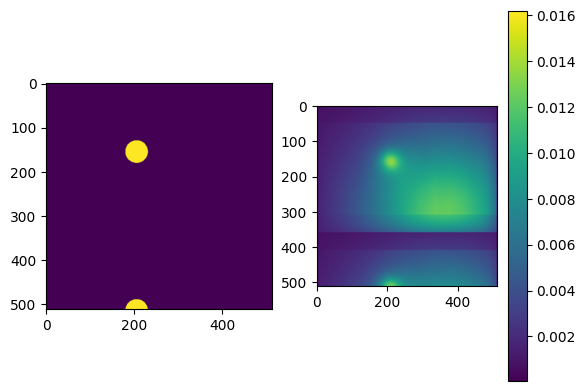

In [17]:
plt.subplot(1,2,1)
plt.imshow(all_targets[:512,:])

plt.subplot(1,2,2)
plt.imshow(all_preds[:512,:])
plt.colorbar()